# Homework 4：DQN and Double DQN
## Due: 23:59:59 (GMT +08:00), May 2, 2024 ##
In this part, we will implement two algorithms in a Pendulum-v1 environment.

You are required to finish  <u>*several*</u>   coding exercises and answer <u>*several*</u> questions in the following notebook.

## Environment Setting :
This environment is part of the
classic control environments. The system in this environment consists of a pendulum attached at one
end to a fixed point and the other end being free. The pendulum begins in a random position and the
objective is to apply torque to the free end to swing it into an upright position. When the pendulum
is upright upwards, a reward of 0 is given, while being in other positions yields a negative reward. The
environment itself has no termination state but the episode truncates at 200 steps.

In this environment, the observation is a ndarray with shape (3,) representing the x-y coordinates of
the pendulum’s free end and its angular velocity.

Num | Observation  | min | max  
----|--------------|-----|----   
0   | $\cos \theta$  | -1.0| 1.0
1   | $\sin \theta$   | -1.0| 1.0
2   |$\dot\theta$  | -8.0| 8.0

The vanilla action space in the environment is continuous, where each action is a ndarray with shape
(1,), representing the torque applied to free end of the pendulum. To apply value-based methods in
this environment, we further discretize the action space into a discrete one, where there are 11 actions
and each discrete action a ∈ {0, 1, . . . , 10} represents torque 0.4 × a − 2. You can refer to the website
for more detailed information about this environment

Num | Action  | min | max  
----|--------------|-----|----   
0   | Torque | -2.0| 2.0



![Pendulum](https://cdn.kesci.com/upload/image/qfoepa3n0z.gif?imageView2/0/w/960/h/960)
&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp; &ensp;&ensp;&ensp;&ensp;&ensp;&ensp;&ensp;   

In [1]:
from collections import deque
import math
import random
import time
import gym   #the latest version of gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import torch.nn.functional as F
from torch.distributions import Normal
import matplotlib.pyplot as plt
from tqdm import tqdm

## DQN and Double DQN algorithm

The optimization function of traditional **DQN** is 
$$
r+\gamma \max _{a^{\prime}} Q_{\theta^-}\left(s', a^{\prime}\right)
$$

This value is computed by target agent ($\theta^-$), It can be shown in following formula
$$
Q_{\theta^-}\left(s', \underset{a'}{\operatorname{argmax}} Q_{\theta^-}\left(s',  a' \right) \right)
$$

In other words, the max operation can actually be broken down into two steps, first selecting the optimal action at state $s'$  :$a^{*} = \underset{a'}{\operatorname{argmax}} Q_{\theta^-}\left(s', a' \right)$ and then compute the relevant Q-value $Q\left(s', a^* \right)$. When these two steps are calculated using the same Q network, each time the obtained is the maximum of all Q values currently estimated by the agent ($\theta^-$). DQN always overestimated the $Q$ value function and the error will cumulate.

To solve this problem, **Double DQN** is proposed to estimate $\max_{a'} Q_*(s', a')$ with two independently trained neural networks.The  approach is to change original function $\max _{a^{\prime}} Q_{\theta^-}\left(s', a^{\prime}\right)$ to 

$$
Q_{\theta^-}\left(s', \underset{a'}{\operatorname{argmax}} Q_{\theta}\left(s',  a' \right) \right)
$$

We use one of the neural networks $Q_{\boldsymbol{\theta}}$ to select an action, and another one $Q_{\boldsymbol{\theta}^{-}}$ to calculate the Q value of the action. In this way, even if the Q-value is overestimated by one network, due to the existence of another one, the final Q value used by this action will not be greatly overestimated, which solves the problem to a certain extent.

In this section, we will try to implement DQN and Double DQN. The implementation of the algorithm is divided into three parts: (1) DQN-base network; (2) Replay buffer; and (3) Learning function.

You may refer to [1] and [2] for the algorithmic details of DQN and Double DQN, respectively.

### DQN-base network

Our agent is a 3-layer MLP, which takes in a vector shape like (state_dim ,) , and outputs a Q-value vector $Q$ with a shape like (action_num, ), where the $i_{th}$ dim of $Q$ means $Q(s,a_{i})$.

In [2]:
class DQN_base(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        raise NotImplementedError

    def act(self, state, epsilon, device, discrete_action_n):
        if random.random() > epsilon:
            with torch.no_grad():
                state = torch.FloatTensor(np.float32(state)).unsqueeze(0).to(device)
                q_value = self.forward(state)
                action = q_value.max(1).indices.item()
        else:
            action = random.randrange(discrete_action_n)
        return action
    

class DQN(DQN_base):
    def __init__(self, input_n, num_actions, h_size=24):
        super(DQN, self).__init__()

        self.input_n = input_n
        self.num_actions = num_actions

        self.fc = nn.Sequential(
            nn.Linear(self.input_n, h_size),
            nn.ReLU(),
            nn.Linear(h_size, h_size),
            nn.ReLU(),
            nn.Linear(h_size, self.num_actions)
        )
        
    def forward(self, x):
        x = self.fc(x)
        return x

### Replay Buffer
**Coding exercises.**

This part you are required to implement (a) the push operation of one sample in function push() and (b) the sample operation of a batch of samples in function sample() 


In [4]:
class ReplayBuffer(object):
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):

        '''
        Args: state (ndarray (3,)), action (int), reward (float), next_state (ndarray (3,)), done (bool)

        No return
        '''
        """ ----------- Programming 1: implement the push operation of one sample ----------- """
        self.buffer.append((state, action, reward, next_state, done))
        """ ----------- Programming 1 ----------- """
        """ ------------- Programming 1 ------------- """

    def sample(self, batch_size):

        '''
        Args: batch_size (int)

        Required return: a batch of states (ndarray, (batch_size, state_dimension)), a batch of actions (list or tuple, length=batch_size),
        a batch of rewards (list or tuple, length=batch_size), a batch of next-states (ndarray, (batch_size, state_dimension)),
        a batch of done flags (list or tuple, length=batch_size)
        '''
        """ ------------- Programming 2: implement the sample operation of a batch of samples (note that to you need to satisfy 
        the format of the return as stated above to make the replay buffer compatible with other components in main.py) ------------- """
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return np.array(state), action, reward, np.array(next_state), done
        """ ------------- Programming 2 ------------- """

    def __len__(self):
        return len(self.buffer)
    



### Learning function and Training loop
**Coding exercises.**

This part you are required to implement 

(a) the computation of the Q values of next-states for Double DQN; 

(b) the computation of the Q values of next-states for vanilla DQN;

(c) the computation of the expected Q values of current states;

(d) the computation of the TD loss in function learn().


You are require to run the following block without editting **any hyperparameter**, **Your output will be one of the criteria we use to score** 


100%|██████████| 30000/30000 [01:07<00:00, 445.25it/s]


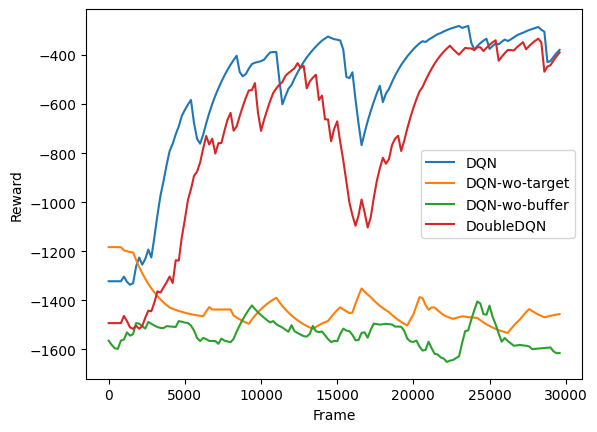

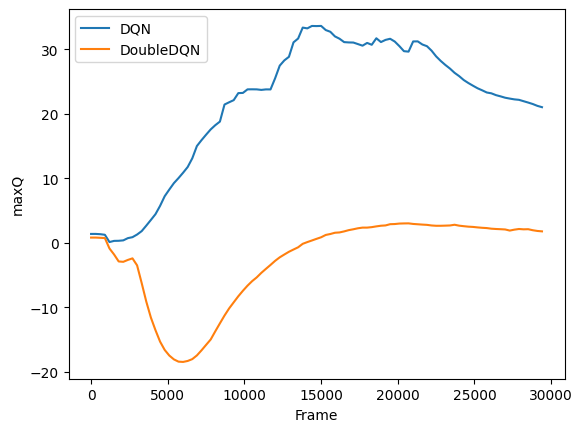

In [9]:
################################################################
##### Learning function
################################################################
def learn(batch_size, current_model, target_model, replay_buffer, optimizer, step=1):
    state, action, reward, next_state, done = replay_buffer.sample(batch_size)
    with torch.no_grad():
        state = torch.FloatTensor(np.float32(state)).to(device)
        next_state = torch.FloatTensor(np.float32(next_state)).to(device)
        action = torch.LongTensor(action).to(device)
        reward = torch.FloatTensor(reward).to(device)
        done = torch.FloatTensor(done).to(device)
    q_values = current_model(state)
    next_q_values = current_model(next_state)
    if USE_TARGET_NET:
        next_q_values_target = target_model(next_state)
    q_value = q_values.gather(1, action.unsqueeze(1)).squeeze(1)
    
    if USE_DOUBLE_Q:
        """ ------------- Programming 3: complete the computation of the Q values of next states for double DQN in the following line of code ------------- """
        next_q_value = next_q_values_target.gather(1, torch.max(next_q_values, 1)[1].unsqueeze(1)).squeeze(1)
        """ ------------- Programming 3 ------------- """
    else:
        if USE_TARGET_NET:
            """ ------------- Programming 4: complete the computation of the Q values of next states for vanilla DQN in the following line of code ------------- """
            next_q_value = next_q_values_target.gather(1, torch.max(next_q_values_target, 1)[1].unsqueeze(1)).squeeze(1)
            """ ------------- Programming 4 ------------- """
        else: # the computation of the Q values of next states for DQN w/o using target networks
            next_q_value = next_q_values.gather(1, torch.max(next_q_values, 1)[1].unsqueeze(1)).squeeze(1)

    """ ------------- Programming 5: complete the computation of the expected Q values of current states in the following line of code (this is same for all DQN variants) ------------- """
    expected_q_value = reward + gamma * next_q_value * (1 - done)
    """ ------------- Programming 5 ------------- """

    """ ------------- Programming 6: complete the computation of the TD loss in the following line of code (this is same for all DQN variants) ------------- """
    loss= F.mse_loss(q_value, expected_q_value).mean() # TD loss, should be time difference, MSE loss
    """ ------------- Programming 6 ------------- """

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



##### reset env
def set_env(env_id):
    global env, env1, discrete_action_n, input_n, faction
    env = gym.make(env_id)
    env1 = gym.make(env_id)
    input_n = env.observation_space.shape[0]
    if not isinstance(env.action_space, gym.spaces.discrete.Discrete):
        discrete_action_n = 11  # [0, discrete_action_n-1]
        action_lowbound = env.action_space.low[0]
        action_upbound = env.action_space.high[0]

        #discrete action to continuous action
        def faction(discrete_n):
            return action_lowbound + (discrete_n / (discrete_action_n - 1)) * (action_upbound - action_lowbound)
        
    else:
        discrete_action_n = env.action_space.n


##### update target agent
def update_target(current_model, target_model):
    target_model.load_state_dict(current_model.state_dict())



################################################################
##### Visualization function
################################################################
def smooth_curve(y, smooth):
    r = smooth
    length = int(np.prod(y.shape))
    for i in range(length):
        if i > 0:
            if (not np.isinf(y[i - 1])) and (not np.isnan(y[i - 1])):
                y[i] = y[i - 1] * r + y[i] * (1 - r)
    return y

def moving_average(y, x=None, total_steps=100, smooth=0.9, move_max=False):
    if isinstance(y, list):
        y = np.array(y)
    length = int(np.prod(y.shape))
    if x is None:
        x = list(range(1, length+1))
    if isinstance(x, list):
        x = np.array(x)
    if length > total_steps:
        block_size = length//total_steps
        select_list = list(range(0, length, block_size))
        select_list = select_list[:-1]
        y = y[:len(select_list) * block_size].reshape(-1, block_size)
        if move_max:
            y = np.max(y, -1)
        else:
            y = np.mean(y, -1)
        x = x[select_list]
    y = smooth_curve(y, smooth)
    return y, x
        
def plotMaxQ(max_Qs):
    plt.clf()
    y, x = moving_average(max_Qs)
    plt.xlabel("frame")
    plt.ylabel("Q value")
    plt.plot(x, y)
    plt.show()
    plt.savefig('MaxQ.png')

def plotReward(all_rewards):
    plt.clf()
    y, x = moving_average(all_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.plot(x, y)
    plt.show()
    plt.savefig('reward.png')

def compareResult(rewards, labels, use_max=False, smooth=0.9, ylabel_name="Reward", filename=None):
    plt.clf()
    plt.ylabel(ylabel_name)
    plt.xlabel("Frame")
    for rs in rewards:
        if not use_max:
            x1 = list(range(0, len(rs)*eval_step, eval_step))
        else:
            x1 = None
        reward1, x1 = moving_average(rs, x1, move_max=use_max, smooth=smooth)
        plt.plot(x1, reward1)
    plt.legend(labels)
    plt.show()



def push_buffer(buffers, sample ,step=1):
    wait_buffer, replay_buffer = buffers
    replay_buffer.push(*sample)
    return wait_buffer
    

def evaluation(current_model):
    state = env1.reset(seed=SEED)[0]
    done = False
    r = 0
    while not done:
        action = current_model.act(state, 0, device, discrete_action_n)
        if not isinstance(env.action_space, gym.spaces.discrete.Discrete):
            next_state, reward, done1,done2, _ = env1.step(np.array([faction(action)]))
        else:
            next_state, reward, done1,done2, _ = env1.step(action)
        done= done1 or done2
        state = next_state
        r += reward
    return r
    
##### the training loop
def train(num_frames,isDueling=False, DQN: DQN_base=None,DuelingDQN: DQN_base= None, multi_step=1):
    
    def maxQ(model, state):
        with torch.no_grad():
            state = torch.FloatTensor(np.float32(state)).unsqueeze(0).to(device)
            q_value = model.forward(state)
            max_q_value = q_value.max(1).values.item()
        return max_q_value
    replay_buffer = ReplayBuffer(replay_buffer_size)
    
    wait_buffer = []
    if isDueling:
        current_model = DuelingDQN(input_n, discrete_action_n, h_size=h_size).to(device)
    else:
        current_model = DQN(input_n, discrete_action_n, h_size=h_size).to(device)
    target_model = None
    if USE_TARGET_NET:
        if isDueling:
            target_model = DuelingDQN(input_n, discrete_action_n, h_size=h_size).to(device)
        else:
            target_model = DQN(input_n, discrete_action_n, h_size=h_size).to(device)
        update_target(current_model, target_model)
    optimizer = optim.Adam(current_model.parameters(), lr=learning_rate)
    max_Qs = []
    now_Q = 0
    all_rewards = []
    episode_reward = 0
    episode = 0
    state = env.reset(seed=SEED)[0]
    for frame_idx in tqdm(range(1, num_frames + 1)):
        t_episode_start = time.process_time()
        epsilon = epsilon_by_frame(frame_idx)
        action = current_model.act(state, epsilon, device, discrete_action_n)
        now_Q = maxQ(current_model, state) 
        max_Qs.append(now_Q)
        if not isinstance(env.action_space, gym.spaces.discrete.Discrete):
            next_state, reward, done1, done2, _ = env.step(np.array([faction(action)]))
        else:
            next_state, reward, done1, done2,_ = env.step(action)
        done=done1 or done2
        wait_buffer = push_buffer((wait_buffer, replay_buffer), (state, action, reward, next_state, done), step=multi_step)
        episode_reward += reward
        state = next_state
        if done:
            state = env.reset()[0]
            episode_reward = 0
            episode += 1
        if frame_idx % eval_step == 0:
            r = evaluation(current_model)
            all_rewards.append(r)
        if len(replay_buffer) >= replay_initial:
            learn(batch_size, current_model, target_model, replay_buffer, optimizer, step=multi_step)
        if frame_idx % update_target_step == 0:
            if USE_TARGET_NET:
                update_target(current_model, target_model)
    return max_Qs, all_rewards



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 9
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
gamma = 0.98

env, env1 = None, None
discrete_action_n, input_n = 0, 0
faction = None

ENV_NAME = "Pendulum-v1"
set_env(ENV_NAME)

num_frames = 30000

epsilon_start = 0.5
epsilon_final = 0.01
epsilon_decay = 1500
epsilon_by_frame = lambda frame_idx: epsilon_final + (epsilon_start - epsilon_final) * math.exp(-1. * frame_idx / epsilon_decay)
update_target_step = 100
learning_rate = 0.01
eval_step = 200
h_size=24

algo_list = ['DQN', 'DQN-wo-target', 'DQN-wo-buffer', 'DoubleDQN']
return_list = []
maxQ_list = []
for ALGO  in algo_list:
    if ALGO == 'DQN': # vanilla DQN
        USE_REPLAY_BUFFER = True
        USE_TARGET_NET = True
        USE_DOUBLE_Q = False
    elif ALGO == 'DQN-wo-target': # DQN w/o using target net
        USE_REPLAY_BUFFER = True
        USE_TARGET_NET = False
        USE_DOUBLE_Q = False
    elif ALGO == 'DQN-wo-buffer': # DQN w/o using replay buffer
        USE_REPLAY_BUFFER = False
        USE_TARGET_NET = True
        USE_DOUBLE_Q = False
    elif ALGO == 'DoubleDQN': # double DQN
        USE_REPLAY_BUFFER = True
        USE_TARGET_NET = True
        USE_DOUBLE_Q = True

    replay_initial = 1000 if USE_REPLAY_BUFFER else 1
    replay_buffer_size = 3000 if USE_REPLAY_BUFFER else 1
    batch_size = 64 if USE_REPLAY_BUFFER else 1

    maxQ_value, episode_return = train(num_frames, DQN=DQN)
    maxQ_list.append(maxQ_value)
    return_list.append(episode_return)

compareResult(return_list, algo_list, filename = 'return_comparison_{}_{}'.format(ENV_NAME, SEED))
compareResult([maxQ_list[0],maxQ_list[3]] , [algo_list[0], algo_list[3]], use_max=True, ylabel_name="maxQ", filename = 'maxQ_comparison_{}_{}'.format(ENV_NAME, SEED))

### Question
**(a)** Compare the performance difference between vanilla DQN and DQN without using the target
network. Discuss the reason for this difference.

**(b)** Compare the performance difference between vanilla DQN and DQN without using the replay
buffer. Discuss the reason for this difference.

**(c)** Compare the performance difference and estimated maximum Q-value between vanilla DQN and
Double DQN. Discuss the reason for this difference.


(a) The first figure shows that the performace of DQN is significantly better than DQM w.o. target network. A target network can help stabilize training. Similar to A2C algorithm, the target network holds the weights of a second Q-network that are updated less frequently, and used to generate the Q-value targets for the loss calculation. This helps to prevent the rapid, potentially destabilizing shifts in Q-value estimations that can occur when the Q-network's weights are updated continuously. Without the target network, these shifts can lead to overestimations of Q-values and result in unstability.

(b) The performance of DQN w.o. replay buffer is similar to DQN w.o. target network. The experience replay buffer stores a history of state transitions, which can be randomly sampled to break the correlation between consecutive training samples, leading to more efficient learning, as the network is trained on a more diverse set of experiences. Without the replay buffer, the DQN can become biased towards the most recent experiences and might overfit to particular sequences of states and actions, which can lead to poor generalization and worse performance, as the figure show.

(c) In the first figure, the reword curves of the two methods have the same trand, and the performance of vanilla DQN is better overall. Since both methods tries to deal with the overestimation problem, given more frames they should reach relatively close performance. The second figure shows double DQM has a lower maxQ value. This indicates that with the design of a Qvalue evaluation method, Double DQN may be providing a more conservative estimate of the Q-values, which *should* help reduce the overoptimistic value estimates that can occur with vanilla DQN, but for some reason it does not work well in this case.

## Reference
[1] Volodymyr Mnih, Koray Kavukcuoglu, David Silver, Andrei A. Rusu, Joel Veness, Marc G. Bellemare,
Alex Graves, Martin A. Riedmiller, Andreas Fidjeland, Georg Ostrovski, Stig Petersen, Charles Beattie,
Amir Sadik, Ioannis Antonoglou, Helen King, Dharshan Kumaran, Daan Wierstra, Shane Legg, and
Demis Hassabis. Human-level control through deep reinforcement learning. Nat., 518(7540):529–533,
2015. URL https://doi.org/10.1038/nature14236.

[2] Hado van Hasselt, Arthur Guez, and David Silver. Deep reinforcement learning with double q-learning.
In Dale Schuurmans and Michael P. Wellman, editors, Proceedings of the Thirtieth AAAI Conference
on Artificial Intelligence, February 12-17, 2016, Phoenix, Arizona, USA, pages 2094–2100. AAAI Press,
2016. URL http://www.aaai.org/ocs/index.php/AAAI/AAAI16/paper/view/12389.